<a href="https://colab.research.google.com/github/sumitgoski/ISM_MachineLearning/blob/main/Alpha_centauri_Habitability_study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

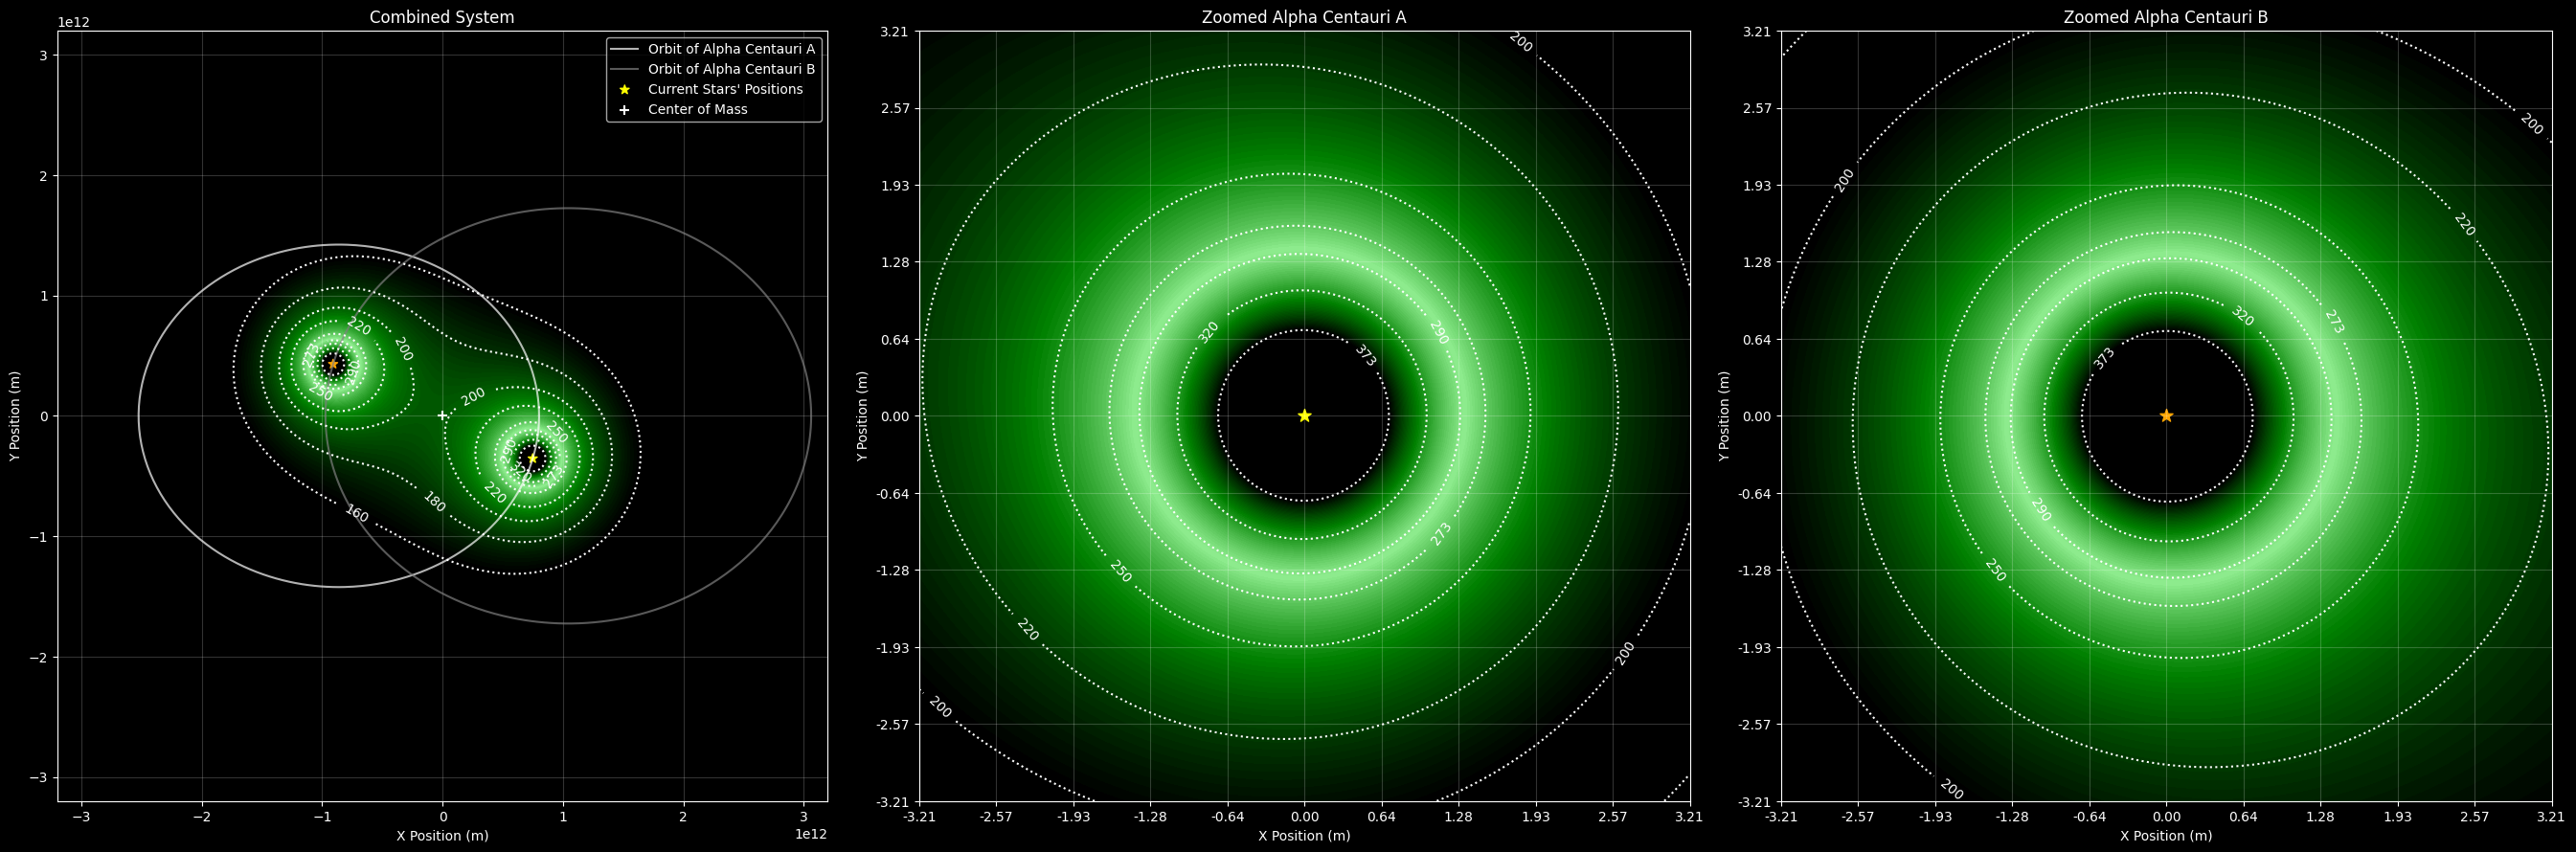

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from datetime import datetime
from matplotlib.colors import LinearSegmentedColormap

# Define the colors for the custom color map
colors = ["black", "green", "lightgreen", "green", "black"]
n_bins = 100  # Smoother transitions

# Create the colormap
custom_cmap = LinearSegmentedColormap.from_list("my_colormap", colors, N=n_bins)

# Constants and star properties
T_star_A = 5800  # Kelvin
T_star_B = 5200  # Kelvin
AU = 1.496e11  # meters
eccentricity = 0.5179
semi_major_axis = 24.6 * AU
M_A = 1.1  # solar masses
M_B = 0.907  # solar masses
r_A = (M_B / (M_A + M_B)) * semi_major_axis
r_B = (M_A / (M_A + M_B)) * semi_major_axis
contour_levels=[160, 180, 200, 220, 250, 273, 290, 320, 373]

def position_elliptical(semi_major, ecc, theta):
    return (semi_major * (1 - ecc**2)) / (1 + ecc * np.cos(theta))

def calculate_positions(theta):
    x_A = position_elliptical(r_A, eccentricity, theta) * np.cos(theta)
    y_A = position_elliptical(r_A, eccentricity, theta) * np.sin(theta)
    x_B = -position_elliptical(r_B, eccentricity, theta) * np.cos(theta)
    y_B = -position_elliptical(r_B, eccentricity, theta) * np.sin(theta)
    return x_A, y_A, x_B, y_B

def calculate_equilibrium_temperature(x, y, x_star, y_star, T_star):
    D = np.sqrt((x - x_star)**2 + (y - y_star)**2) / AU
    T_eq = T_star * (0.0446 * D**(-0.502))
    return T_eq

def current_positions():
    periastron_date = datetime(1950, 1, 1)
    current_date = datetime.now()
    days_since_periastron = (current_date - periastron_date).days
    orbital_period_days = 79.91 * 365.25
    fraction_orbit_completed = (days_since_periastron % orbital_period_days) / orbital_period_days
    theta_current = 2 * np.pi * fraction_orbit_completed
    return calculate_positions(theta_current)

def create_zoomed_plot(ax, x_star, y_star, T_star_A, T_star_B, label, color):
    zoom_plot_range = 0.15 * 3.2e12  # Define the range of the zoomed plot in meters
    grid_resolution = 800  # Higher grid resolution for better detail
    x_zoom = np.linspace(x_star - zoom_plot_range, x_star + zoom_plot_range, grid_resolution)
    y_zoom = np.linspace(y_star - zoom_plot_range, y_star + zoom_plot_range, grid_resolution)
    X_zoom, Y_zoom = np.meshgrid(x_zoom, y_zoom)

    # Calculate the temperature field centered on both stars
    Temp_field_zoom = calculate_equilibrium_temperature(X_zoom, Y_zoom, x_A_current, y_A_current, T_star_A) + \
                      calculate_equilibrium_temperature(X_zoom, Y_zoom, x_B_current, y_B_current, T_star_B)

    # Plot the temperature field
    ax.imshow(Temp_field_zoom, extent=(x_star - zoom_plot_range, x_star + zoom_plot_range,
                                       y_star - zoom_plot_range, y_star + zoom_plot_range),
              origin='lower', cmap=custom_cmap, norm=Normalize(vmin=200, vmax=373), interpolation='bilinear')

    # Mark the star position
    ax.scatter(x_star, y_star, color=color, s=100, marker='*')
    ax.set_title(f'Zoomed {label}')

    # Add temperature contours for clarity
    CS = ax.contour(X_zoom, Y_zoom, Temp_field_zoom, levels=contour_levels, colors='white', linestyles='dotted')
    ax.clabel(CS, inline=True, fontsize=10)

    # Set up the grid and ticks centered on the star, measured in AUs
    AU_in_meters = 1.496e11
    num_ticks = 5  # Number of ticks on either side of the star
    tick_positions = np.linspace(-zoom_plot_range, zoom_plot_range, num_ticks * 2 + 1)
    tick_labels = [f"{tick/AU_in_meters:.2f}" for tick in tick_positions]  # Convert meter offset to AU

    ax.set_xticks(x_star + tick_positions)
    ax.set_yticks(y_star + tick_positions)
    ax.set_xticklabels(tick_labels)
    ax.set_yticklabels(tick_labels)

    ax.grid(True, alpha=0.2)
    ax.set_aspect('equal')
    ax.set_xlabel('X Position (AU)')
    ax.set_ylabel('Y Position (AU)')

theta = np.linspace(0, 2 * np.pi, 500)
x_A, y_A, x_B, y_B = calculate_positions(theta)
x_A_current, y_A_current, x_B_current, y_B_current = current_positions()
x_COM = (M_A * x_A_current + M_B * x_B_current) / (M_A + M_B)
y_COM = (M_A * y_A_current + M_B * y_B_current) / (M_A + M_B)

plot_range = 3.2e12
grid_resolution = 800  # Increased from 400 to 800
x = np.linspace(-plot_range, plot_range, grid_resolution)
y = np.linspace(-plot_range, plot_range, grid_resolution)
X, Y = np.meshgrid(x, y)
Temp_field = calculate_equilibrium_temperature(X, Y, x_A_current, y_A_current, T_star_A) + \
             calculate_equilibrium_temperature(X, Y, x_B_current, y_B_current, T_star_B)

plt.style.use('dark_background')
fig, axs = plt.subplots(1, 3, figsize=(27, 9))

# Main plot
main_ax = axs[0]
main_ax.imshow(Temp_field, extent=(-plot_range, plot_range, -plot_range, plot_range), origin='lower', cmap=custom_cmap, norm=Normalize(vmin=160, vmax=373), interpolation='bilinear')
main_ax.plot(x_A, y_A, color='white', linestyle='-', alpha=0.7, label="Orbit of Alpha Centauri A")
main_ax.plot(x_B, y_B, color='gray', linestyle='-', alpha=0.7, label="Orbit of Alpha Centauri B")
main_ax.scatter([x_A_current, x_B_current], [y_A_current, y_B_current], color=['yellow', 'orange'], s=50, marker='*', label="Current Stars' Positions")
main_ax.scatter(x_COM, y_COM, color='white', s=50, marker="+", label="Center of Mass")
main_ax.set_title('Combined System')
CS = main_ax.contour(X, Y, Temp_field, levels=contour_levels, colors='white', linestyles='dotted')
main_ax.clabel(CS, inline=True, fontsize=10)
main_ax.legend()
main_ax.grid(True, alpha=0.2)

# Zoomed plots for Alpha Centauri A and B
create_zoomed_plot(axs[1], x_A_current, y_A_current, T_star_A, T_star_B, "Alpha Centauri A", 'yellow')
create_zoomed_plot(axs[2], x_B_current, y_B_current, T_star_B, T_star_A, "Alpha Centauri B", 'orange')

for ax in axs:
    ax.set_xlabel('X Position (m)')
    ax.set_ylabel('Y Position (m)')

plt.tight_layout()
plt.show()
